In [1]:
!gcloud auth application-default login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=vNvUAUVunra353OHX5GpvxHHJdGjye&access_type=offline&code_challenge=cqj0eicubjxKjehzjr9rlnArCx16qccWrltA9ALwXcU&code_challenge_method=S256


Credentials saved to file: [/Users/yt4/.config/gcloud/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).

Quota project "open-targets-genetics-dev" was added to ADC which can be used by Google client libraries for billing and quota. Note that some services may still bill the project owning the resource.


Updates are available for some Google Clo

In [2]:
import os

import hail as hl
import numpy as np
import pyspark.sql.functions as f
from pyspark.sql import DataFrame

from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.summary_statistics import SummaryStatistics
from gentropy.dataset.study_locus import StudyLocus
from gentropy.susie_finemapper import SusieFineMapperStep
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment

"""Common utilities for the project."""

import os
from pathlib import Path
from gentropy.common.session import Session
import logging


def get_gcs_credentials() -> str:
    """Get the credentials for google cloud storage."""
    app_default_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/application_default_credentials.json"
    )

    service_account_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/service_account_credentials.json"
    )

    if Path(app_default_credentials).exists():
        return app_default_credentials
    else:
        raise FileNotFoundError("No GCS credentials found.")


def get_gcs_hadoop_connector_jar() -> str:
    """Get the google cloud storage hadoop connector for spark.

    This function will return the url to download the hadoop jar.
    """

    return (
        "https://storage.googleapis.com/hadoop-lib/gcs/gcs-connector-hadoop3-latest.jar"
    )


def gcs_conf(
    credentials_path=None, project="open-targets-genetics-dev"
) -> dict[str, str]:
    """Get the spark configuration with hadoop connector for google cloud storage."""
    credentials_path = credentials_path or get_gcs_credentials()
    return {
        "spark.driver.memory": "12g",
        "spark.kryoserializer.buffer.max": "500m",
        "spark.driver.maxResultSize":"2g",
        "spark.hadoop.fs.gs.impl": "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem",
        "spark.jars": get_gcs_hadoop_connector_jar(),
        "spark.hadoop.google.cloud.auth.service.account.enable": "true",
        "spark.hadoop.fs.gs.project.id": project,
        "spark.hadoop.google.cloud.auth.service.account.json.keyfile": credentials_path,
        "spark.hadoop.fs.gs.requester.pays.mode": "AUTO",
    }


class GentropySession(Session):
    def __init__(self, *args, **kwargs):
        if "extended_spark_conf" in kwargs:
            kwargs["extended_spark_conf"].update(gcs_conf())
        else:
            kwargs["extended_spark_conf"] = gcs_conf()
        super().__init__(*args, **kwargs)

    @property
    def conf(self):
        logging.warning(
            "To change the config restart the session and use the `extended_spark_conf` parameter."
        )
        return self.spark.sparkContext.getConf().getAll()

session= GentropySession()


Loading BokehJS ...

/Users/yt4/Projects/gentropy/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/16 16:09:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
path_to_release_folder="gs://open-targets-data-releases/25.06/"


si=StudyIndex.from_parquet(session,path_to_release_folder+"output/study/")
sl=StudyLocus.from_parquet(session,path_to_release_folder+"output/credible_set/")

sl_eff=session.spark.read.parquet("gs://genetics-portal-dev-analysis/ss60/gentropy-manuscript/chapters/variant-effect-prediction/25.07/lead_variant_effect")

l2g_full=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS.parquet")

In [4]:
qd_cs=session.spark.read.parquet("gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_credible_sets").select("studyLocusId").cache()
qd_cs.count()

70618

In [5]:
sl_eff=session.spark.read.parquet("gs://genetics-portal-dev-analysis/ss60/gentropy-manuscript/chapters/variant-effect-prediction/25.07/lead_variant_effect")
sl_eff=sl_eff.drop("leadVariantConsequence").withColumn("absEstimatedBeta",f.abs(f.col("rescaledStatistics.estimatedBeta"))).withColumn("maf",f.col("majorLdPopulationMaf.value"))

In [6]:
sl_eff.show(1)

+--------------+--------------------+--------------------+----------+------+------------+---------------------+--------------------+-----------------+----------+--------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------------+-------------------+-------------------+
|     variantId|             variant|        studyLocusId|   studyId|geneId|originalBeta|originalStandardError|     locusStatistics|finemappingMethod|isTransQtl|       variantEffect|majorLdPopulation|majorLdPopulationMaf| majorLdPopulationAf|   variantStatistics|     studyStatistics|  rescaledStatistics|traitFromSourceMappedIds|   absEstimatedBeta|                maf|
+--------------+--------------------+--------------------+----------+------+------------+---------------------+--------------------+-----------------+----------+--------------------+-----------------+--------------------+--------------------+----------------

In [7]:
sl_eff=sl_eff.join(qd_cs,"studyLocusId","inner").cache()
sl_eff.count()

70618

In [11]:
sl_eff.select("variantId").distinct().count()

40706

In [8]:
l2g_full=l2g_full.join(qd_cs,"studyLocusId","inner").cache()
l2g_full.count()

70400

In [12]:
severity_score = (
    session.spark.read.option("header", "true")
    .option("sep", "\t")
    .csv("/Users/yt4/Projects/gentropy/notebooks/gentropy_paper/data/otar2503_directAssoc_severity_scores.txt")
    .cache()
)
severity_score.show(1)

+-----------+------------------+------------------+
|  diseaseId|              name|    severity_score|
+-----------+------------------+------------------+
|EFO_0000613|myxoid liposarcoma|0.6588220308195334|
+-----------+------------------+------------------+
only showing top 1 row



In [13]:
si_df=si.df.select("studyId","diseaseIds").cache()
si_df.count()

25/10/16 16:11:04 WARN CacheManager: Asked to cache already cached data.


1966178

In [21]:
sl_eff_beta=sl_eff.join(si.df.select("studyId","diseaseIds"), on="studyId", how="inner").cache()
sl_eff_beta.count()


70618

In [22]:
sl_eff_beta_expl=sl_eff_beta.withColumn("diseaseId",f.explode("diseaseIds")).drop("diseaseIds").cache()
sl_eff_beta_expl.count()

77405

In [24]:
sl_eff_beta_expl.write.parquet("./data/varaint_effects_diseases")

In [14]:
si_df_exploded = si_df.select("studyId", f.explode("diseaseIds").alias("diseaseId")).cache()
si_df_exploded.count()

25/10/16 16:11:05 WARN CacheManager: Asked to cache already cached data.


108620

In [15]:
si_df_exploded_ss=si_df_exploded.join(severity_score.select("diseaseId", "severity_score"), "diseaseId", "left").cache()
si_df_exploded_ss.count()

108620

In [16]:
si_df_exploded_ss.show(1)

+-----------+--------------------+------------------+
|  diseaseId|             studyId|    severity_score|
+-----------+--------------------+------------------+
|EFO_0004237|FINNGEN_R12_AUTOI...|0.5311601239812712|
+-----------+--------------------+------------------+
only showing top 1 row



In [17]:
si_df_exploded_ss = si_df_exploded_ss.fillna(0.01)

In [18]:
from pyspark.sql import Window

# Define window partitioned by studyId and ordered by severity_score descending
window_spec = Window.partitionBy("studyId").orderBy(f.col("severity_score").desc())

# Add row number and filter for rank 1
si_df_max_severity = (
    si_df_exploded_ss
    .withColumn("rank", f.row_number().over(window_spec))
    .filter(f.col("rank") == 1)
    .drop("rank")
    .cache()
)
si_df_max_severity.count()

100526

In [ ]:
sl_eff_beta=sl_eff_beta.join(si.df.select("studyId","diseaseIds"), on="studyId", how="inner").cache()

In [19]:
si_df_max_severity.show()

+-------------+--------------------+-------------------+
|    diseaseId|             studyId|     severity_score|
+-------------+--------------------+-------------------+
|  EFO_0001068|FINNGEN_R12_AB1_M...| 0.5110811691975821|
|  EFO_0004237|FINNGEN_R12_AUTOI...| 0.5311601239812712|
|MONDO_0002354|FINNGEN_R12_CD2_B...| 0.5455049618208088|
|  EFO_0009675|FINNGEN_R12_CD2_B...| 0.5314186820857796|
|MONDO_0004641|FINNGEN_R12_CD2_I...|  0.584224097707534|
|  EFO_0005952|FINNGEN_R12_CD2_N...| 0.7010682931538996|
|  EFO_0005539|FINNGEN_R12_E4_AD...| 0.5784667348716027|
|MONDO_0001330|FINNGEN_R12_H7_PR...|0.41027432147065135|
|  EFO_0003763|FINNGEN_R12_I9_CE...|  0.720663625978737|
|  EFO_0000712|  FINNGEN_R12_I9_STR| 0.6392126164271471|
|MONDO_0002342|FINNGEN_R12_M13_C...|  0.558842066727072|
|  EFO_0003874|FINNGEN_R12_M13_F...| 0.4558676836295432|
|  EFO_0007202|FINNGEN_R12_O15_M...| 0.4312515980767385|
|  EFO_0009434|FINNGEN_R12_P16_F...|               NULL|
|  EFO_0004685|          GCST00

In [20]:
sl_eff_beta=sl_eff.withColumn("beta",f.col("rescaledStatistics.estimatedBeta")).select("studyLocusId","studyId","beta","variantId","maf").cache()
sl_eff_beta.count()

70618

In [21]:
sl_eff_beta=sl_eff_beta.join(si_df_max_severity.select("studyId","severity_score"),"studyId","inner").cache()
sl_eff_beta.count()

70618

In [22]:
sl_eff_beta.show(1)

+--------------------+--------------------+--------------------+----------------+-------------------+------------------+
|             studyId|        studyLocusId|                beta|       variantId|                maf|    severity_score|
+--------------------+--------------------+--------------------+----------------+-------------------+------------------+
|FINNGEN_R12_RHEUM...|fa58d8b83bdefe17f...|-0.08887719142312035|6_137968604_GA_G|0.22860658841347975|0.5963756796628045|
+--------------------+--------------------+--------------------+----------------+-------------------+------------------+
only showing top 1 row



In [29]:
sl_eff_beta=sl_eff_beta.join(si.df.select("studyId","diseaseIds"), on="studyId", how="inner").cache()
sl_eff_beta.count()

70618

In [30]:
sl_eff_beta_expl=sl_eff_beta.withColumn("diseaseId",f.explode("diseaseIds")).drop("diseaseIds").cache()
sl_eff_beta_expl.count()

77405

In [31]:
sl_eff_beta_expl.show(1)

+--------------------+--------------------+------------------+---------------+-------------------+------------------+-----------+
|             studyId|        studyLocusId|              beta|      variantId|                maf|    severity_score|  diseaseId|
+--------------------+--------------------+------------------+---------------+-------------------+------------------+-----------+
|FINNGEN_R12_AUTOI...|fc0ef9cbd5db60b3d...|0.3619660154228197|10_62188127_A_G|0.05796418473138549|0.5311601239812712|EFO_0004237|
+--------------------+--------------------+------------------+---------------+-------------------+------------------+-----------+
only showing top 1 row



In [34]:
from pyspark.sql import Window

# Define window partitioned by diseaseId and ordered by abs(beta) descending
window_spec = Window.partitionBy("variantId","diseaseId").orderBy(f.abs(f.col("beta")).desc())

# Add row number and filter for rank 1 (highest abs(beta) per diseaseId)
sl_eff_beta_expl_max = (
    sl_eff_beta_expl
    .withColumn("rank", f.row_number().over(window_spec))
    .filter(f.col("rank") == 1)
    .drop("rank")
    .cache()
)

sl_eff_beta_expl_max.count()

60229

In [35]:
sl_eff_beta_expl_max.select("variantId").distinct().count()

40706

In [49]:
sl_eff_beta_agg = (
    sl_eff_beta_expl_max
    .groupBy("variantId")
    .agg(
        f.abs(f.sum("beta")).alias("sum_beta_variant"),
        f.abs(f.sum(f.col("beta")*f.col("severity_score"))).alias("weighted_sum_beta_variant"),
        f.count("*").alias("count_rows"),
        f.max(f.col("maf")).alias("max_maf_variant")
        )
    .cache()
)
sl_eff_beta_agg.count()

40706

In [50]:
sl_eff_beta_agg.show(1)

+---------------+------------------+-------------------------+----------+------------------+
|      variantId|  sum_beta_variant|weighted_sum_beta_variant|count_rows|   max_maf_variant|
+---------------+------------------+-------------------------+----------+------------------+
|1_176005154_T_C|0.0662802822739042|      0.02629806421386129|         3|0.4424787133396405|
+---------------+------------------+-------------------------+----------+------------------+
only showing top 1 row



In [51]:
correlation = sl_eff_beta_agg.stat.corr("sum_beta_variant", "weighted_sum_beta_variant")
print(f"Correlation: {correlation}")

Correlation: 0.9866741705087348


In [52]:
x=session.spark.read.csv("/Users/yt4/Desktop/PSs/variants_with_residuals.csv",header=True,inferSchema=True)

In [53]:
x.show(1)

+----------------+----------------+-------------------+-------------------+---------------------------+---------------------------+----------------------+----------------------+-----------------+-----------------+------------------+---------------+-----------+-------------------+-----------------------+--------------+----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+------------+------------------+--------+----------------------+------------------------------+-----------------------

In [54]:
x.count()

40706

In [55]:
x=x.join(sl_eff_beta_agg,on="variantId",how="inner").cache()

In [56]:
x.count()

40706

In [57]:
x.toPandas().to_csv("/Users/yt4/Desktop/PSs/variants_with_fitness_scores.csv",index=False)

In [9]:
y=session.spark.read.csv("/Users/yt4/Desktop/PSs/variants_with_fitness_scores.csv",header=True,inferSchema=True)

In [12]:
y.show(1)

+----------------+----------------+-------------------+-------------------+---------------------------+---------------------------+----------------------+----------------------+-----------------+-----------------+------------------+---------------+-----------+-------------------+-----------------------+--------------+----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+------------+------------------+--------+----------------------+------------------------------+-----------------------

In [13]:
y = y.withColumn("weighted_sum_beta_variant", f.abs(f.col("weighted_sum_beta_variant")))

In [19]:
y = y.withColumn("sum_beta_variant", f.abs(f.col("sum_beta_variant")))

In [17]:
l2g_full=l2g_full.join(sl.df.select("studyLocusId","variantId"),"studyLocusId","inner").cache()
l2g_full.count()

70400

In [18]:
l2g_full.show(1)

+--------------------+---------------+------------------+----------+----------+---+-----------+---------------+
|        studyLocusId|         geneId|             score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|      variantId|
+--------------------+---------------+------------------+----------+----------+---+-----------+---------------+
|0590e724aa69711f7...|ENSG00000108551|0.7999526262283325|         0|         0|  0|          1|17_17496321_C_T|
+--------------------+---------------+------------------+----------+----------+---+-----------+---------------+
only showing top 1 row



In [20]:
l2g_full=l2g_full.join(y.select("variantId","weighted_sum_beta_variant","sum_beta_variant"),"variantId","inner").cache()
l2g_full.count()

70400

In [21]:
l2g_full.show(1)

+---------------+--------------------+---------------+------------------+----------+----------+---+-----------+-------------------------+--------------------+
|      variantId|        studyLocusId|         geneId|             score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|weighted_sum_beta_variant|    sum_beta_variant|
+---------------+--------------------+---------------+------------------+----------+----------+---+-----------+-------------------------+--------------------+
|17_17496321_C_T|0590e724aa69711f7...|ENSG00000108551|0.7999526262283325|         0|         0|  0|          1|      0.00375280398473435|0.016292858169678993|
+---------------+--------------------+---------------+------------------+----------+----------+---+-----------+-------------------------+--------------------+
only showing top 1 row



In [26]:
l2g_full_genes_fs = (
    l2g_full
    .select("geneId", "variantId", "weighted_sum_beta_variant", "sum_beta_variant")
    .distinct()  # Remove duplicate geneId-variantId combinations
    .groupBy("geneId")
    .agg(
        f.sum(f.col("weighted_sum_beta_variant")).alias("sum_weighted_sum_beta_variant"),
        f.sum(f.col("sum_beta_variant")).alias("sum_sum_beta_variant"),
        f.count("*").alias("count_variants_per_gene")
    )
    .cache()
)
l2g_full_genes_fs.count()

8285

In [23]:
l2g_full_genes_fs=(
    l2g_full
    .groupBy("geneId")
    .agg(
        f.sum(f.col("weighted_sum_beta_variant")).alias("sum_weighted_sum_beta_variant"),
        f.sum(f.col("sum_beta_variant")).alias("sum_sum_beta_variant"),
        f.count("*").alias("count_variants_per_gene")
    )
    .cache()
)
l2g_full_genes_fs.count()

8285

In [27]:
l2g_full_genes_fs.show()

+---------------+-----------------------------+--------------------+-----------------------+
|         geneId|sum_weighted_sum_beta_variant|sum_sum_beta_variant|count_variants_per_gene|
+---------------+-----------------------------+--------------------+-----------------------+
|ENSG00000163406|          0.18218312271635978|  0.3991568297354272|                      6|
|ENSG00000168314|           0.8222286533923305|   1.286454445066255|                      5|
|ENSG00000172765|           1.0539497417006387|   1.622023294067363|                      2|
|ENSG00000145723|          0.21882464866574297|  0.4218682448682486|                      4|
|ENSG00000105993|           0.2095017615236954|  0.5073970265334039|                      1|
|ENSG00000196950|          0.04686898312052479| 0.08523395379927355|                      3|
|ENSG00000115252|          0.14661253996343904|  0.3029099097947857|                      8|
|ENSG00000143013|           0.7340971325823458|  1.2226410352756079|  

In [29]:
l2g_full_genes_fs.write.mode("overwrite").parquet("/Users/yt4/Desktop/PSs/list_of_prioritised_genes_with_FS.parquet")

25/10/15 02:56:15 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 909863 ms exceeds timeout 120000 ms
25/10/15 02:56:15 WARN SparkContext: Killing executors is not supported by current scheduler.
25/10/15 02:56:24 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [23]:
#l2g_full.count()

In [24]:
#l2g_full=l2g_full.join(sl_eff_beta, "studyLocusId", "inner").cache()
#l2g_full.count()

In [25]:
#l2g_full.show(1)

In [ ]:
#l2g_full=l2g_full.join(si.df.select("studyId","diseaseIds"), on="studyId", how="inner").cache()
#l2g_full.count()

70400

In [26]:
#l2g_full.show()

In [25]:
l2g_full_exploded = l2g_full.withColumn("diseaseId", f.explode("diseaseIds")).cache()
l2g_full_exploded.count()

77071

In [26]:
from pyspark.sql import Window

# Define window partitioned by geneId and diseaseId, ordered by abs(beta) descending
window_spec = Window.partitionBy("geneId", "diseaseId").orderBy(f.abs(f.col("beta")).desc())

# Add row number and filter for rank 1
l2g_max_beta = (
    l2g_full_exploded
    .withColumn("rank", f.row_number().over(window_spec))
    .filter(f.col("rank") == 1)
    .drop("rank")
    .cache()
)
l2g_max_beta.count()

36858

In [27]:
l2g_max_beta.show()

+--------------------+--------------------+---------------+-------------------+----------+----------+---+-----------+--------------------+-----------------+-------------------+-------------------+--------------------+-------------+
|             studyId|        studyLocusId|         geneId|              score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                beta|        variantId|                maf|     severity_score|          diseaseIds|    diseaseId|
+--------------------+--------------------+---------------+-------------------+----------+----------+---+-----------+--------------------+-----------------+-------------------+-------------------+--------------------+-------------+
|FINNGEN_R12_J10_U...|2518f2b96d444b529...|ENSG00000001617|0.25239813327789307|         1|         0|  0|          0|0.026782687708104023|  3_49999769_GA_G| 0.4024640657084189|0.47526507855967504|     [MONDO_0004867]|MONDO_0004867|
|        GCST90454586|0425a9a9be24290c4...|ENSG00000002822|0.39857763051

In [28]:
l2g_agg_variant = (
    l2g_max_beta
    #.groupBy("variantId","geneId")
    .groupBy("variantId")
    .agg(
        f.abs(f.sum("beta")).alias("sum_beta_variant"),
        f.abs(f.sum(f.col("beta")*f.col("severity_score"))).alias("weighted_sum_beta_variant"),
        f.count("*").alias("count_rows"),
        f.max(f.col("maf")).alias("max_maf_variant")
        )
    .cache()
)
l2g_agg_variant.count()

25467

In [29]:
l2g_agg_variant.show(1)

+----------------+-------------------+-------------------------+----------+-------------------+
|       variantId|   sum_beta_variant|weighted_sum_beta_variant|count_rows|    max_maf_variant|
+----------------+-------------------+-------------------------+----------+-------------------+
|11_66304152_A_AT|0.08634671601281466|      0.04344902044010596|         2|0.47086368366285125|
+----------------+-------------------+-------------------------+----------+-------------------+
only showing top 1 row



In [31]:
correlation = l2g_agg_variant.stat.corr("sum_beta_variant", "weighted_sum_beta_variant")
print(f"Correlation: {correlation}")

Correlation: 0.985815681286536


In [32]:
l2g_agg_variant_df=l2g_agg_variant.toPandas()

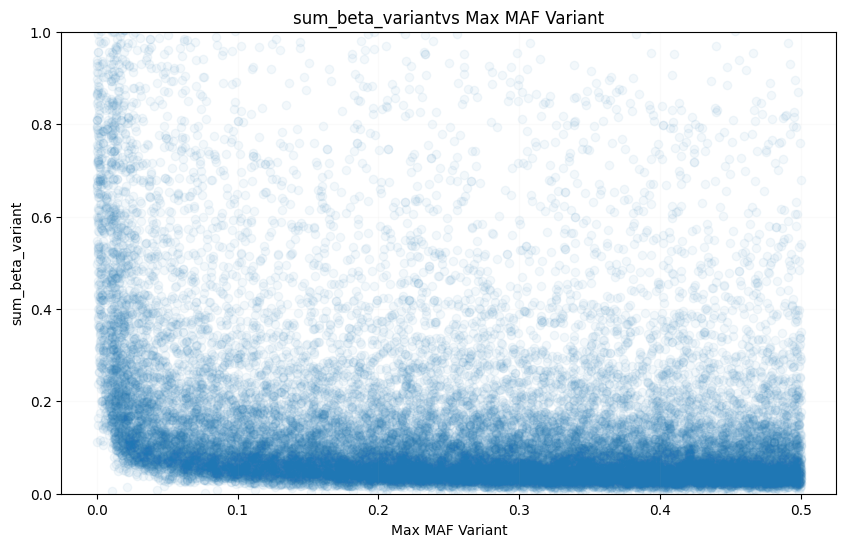

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(l2g_agg_variant_df['max_maf_variant'], 
           l2g_agg_variant_df['sum_beta_variant'], 
           alpha=0.05)
plt.xlabel('Max MAF Variant')
plt.ylabel('sum_beta_variant')
plt.title('sum_beta_variantvs Max MAF Variant')
plt.grid(True, alpha=0.05)
plt.ylim(0,1)
plt.show()

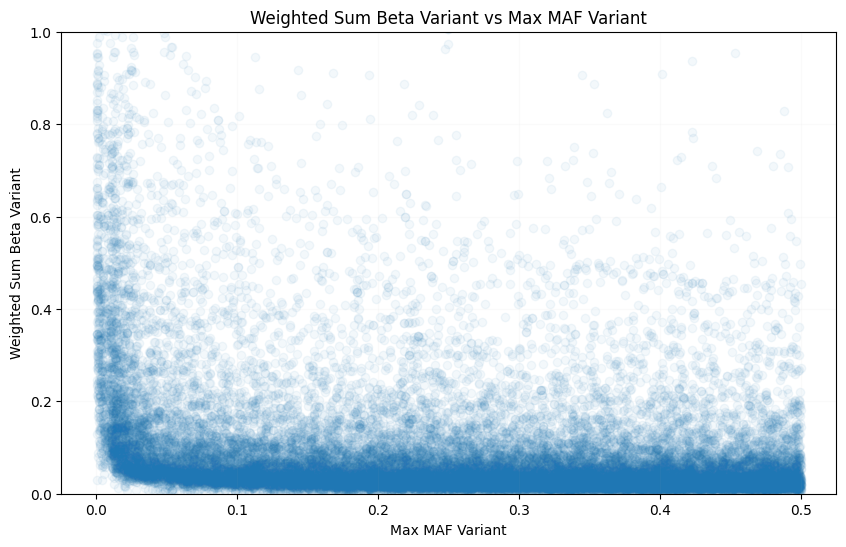

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(l2g_agg_variant_df['max_maf_variant'], 
           l2g_agg_variant_df['weighted_sum_beta_variant'], 
           alpha=0.05)
plt.xlabel('Max MAF Variant')
plt.ylabel('Weighted Sum Beta Variant')
plt.title('Weighted Sum Beta Variant vs Max MAF Variant')
plt.grid(True, alpha=0.05)
plt.ylim(0,1)
plt.show()

In [39]:
l2g_agg = (
    l2g_agg_variant
    .groupBy("geneId")
    .agg(
        f.sum("sum_beta_variant").alias("abs_sum_beta"),
        f.sum(f.col("weighted_sum_beta_variant")).alias("abs_weighted_sum_beta"),
        f.count("*").alias("count_rows")
        )
    .cache()
)
l2g_agg.count()

8285

In [40]:
l2g_agg.show(1)

+---------------+-----------------+---------------------+----------+
|         geneId|     abs_sum_beta|abs_weighted_sum_beta|count_rows|
+---------------+-----------------+---------------------+----------+
|ENSG00000224578|1.832713025263984|    0.924102175799243|        12|
+---------------+-----------------+---------------------+----------+
only showing top 1 row



In [41]:
top_10 = l2g_agg.orderBy(f.desc("abs_weighted_sum_beta")).limit(10)
top_10.show()

+---------------+------------------+---------------------+----------+
|         geneId|      abs_sum_beta|abs_weighted_sum_beta|count_rows|
+---------------+------------------+---------------------+----------+
|ENSG00000183765|29.726299523390498|   20.374556799187893|        18|
|ENSG00000198670| 23.06781246407785|   14.230405967806414|        13|
|ENSG00000147883| 22.81236771103064|   14.007060307406363|        83|
|ENSG00000198734|23.064584493446123|   13.500174470253556|         7|
|ENSG00000141510|21.273543571666494|   13.483871279437391|         2|
|ENSG00000130203| 17.72967031595722|   11.154955666096273|        15|
|ENSG00000180210| 16.81999971292247|     10.4908720792966|         7|
|ENSG00000137265|17.333331856785513|    9.986272405587169|        20|
|ENSG00000164362|14.614435029380681|    9.805708817724563|        26|
|ENSG00000197249|15.500419565819755|     8.93712006168806|         4|
+---------------+------------------+---------------------+----------+



In [43]:
top_10 = l2g_agg.orderBy(f.desc("abs_sum_beta")).limit(10)
top_10.show()

+---------------+------------------+---------------------+----------+
|         geneId|      abs_sum_beta|abs_weighted_sum_beta|count_rows|
+---------------+------------------+---------------------+----------+
|ENSG00000183765|29.726299523390498|   20.374556799187893|        18|
|ENSG00000198670| 23.06781246407785|   14.230405967806414|        13|
|ENSG00000198734|23.064584493446123|   13.500174470253556|         7|
|ENSG00000147883| 22.81236771103064|   14.007060307406363|        83|
|ENSG00000141510|21.273543571666494|   13.483871279437391|         2|
|ENSG00000130203| 17.72967031595722|   11.154955666096273|        15|
|ENSG00000137265|17.333331856785513|    9.986272405587169|        20|
|ENSG00000180210| 16.81999971292247|     10.4908720792966|         7|
|ENSG00000182095|16.544675333809298|    8.526491748331825|         4|
|ENSG00000196628|15.577517553339636|   7.1536270564879745|        27|
+---------------+------------------+---------------------+----------+



In [44]:
l2g_agg.write.mode("overwrite").parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/gene_list_fitness_scores.parquet")